In [33]:
# import needed python libraries

%matplotlib inline

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random
import statistics


### Dataset

You will use a dataset collected in July 2019 with statistics from the traffic using a tool called
Tstat (http://tstat.polito.it/). Tstat is a passive traffic monitor that exports flow records, i.e., a
single entry for each TCP/UDP stream in the network. Each flow record is composed of a rich
set of statistics.
The basic objects that passive monitoring tools capture are the packets that are transmitted
on the monitored link. We can group packets in flows if they share key IP header
information. A common choice is to consider: \
**Flow = (Protocol, IP Source Address, Source Port, IP Destination Address, Destination Port)** \
Tstat automatically aggregates by flow the traffic (packets) captured.
Beside classical flow-level fields, such as IP addresses, port numbers, packet and byte-wise
counters, Tstat extracts the domain names, which we use to label the TCP flows. The final
dataset is composed of 125 features, 122 numerical described with an initial “_” in the
featurename, plus the client IP address, the time when this flow was generated and the
label. We removed the information about the server IP.
You can find more information regarding the features in the file readme.txt.
The data provided is already divided in 2 parts for training (https_training.csv) and test
(https_test.csv).

Start the dataset on python. Substitute to the appropriate path to the dataset in your system

In [34]:
df_test = pd.read_csv(r'C:\Users\loren\OneDrive\Desktop\PoliTo\machine Learning\https_test.csv')

df_train = pd.read_csv(r'C:\Users\loren\OneDrive\Desktop\PoliTo\machine Learning\https_training.csv')


### Objective

Explore the dataset and learn about feature behavior at different levels. Use various data \
visualization techniques and statistical analysis \
Produce different visualizations and statistical analysis grouping the data at the flow level \
(rows of the dataset), at the IP level (clients) and domain name level (labels).



#### 1.1

Distributions of features (EPDF or ECDF) per flow, domain name or IP


In [35]:
#how many different IPs/domain name in the dataset
print(f"there are {len(df_train)} different flows")
print(f"there are {len(df_train.groupby('c_ip'))} different client IPs")
print(f"there are {len(df_train.groupby('label'))} different Domains")


there are 147863 different flows
there are 738 different client IPs
there are 26 different Domains


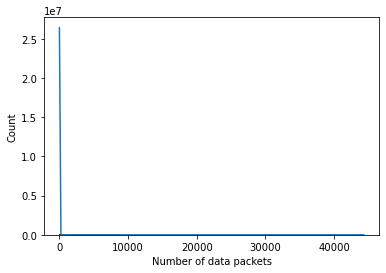

In [ ]:
plt.figure()
sns.histplot(data=df_train, x='_c_pkts_data', bins=5, kde=True)
plt.xlabel(f'Number of data packets')
plt.show()

_c_mss 90% of its data equal to each other
_c_pkts_dup 90% of its data equal to each other
_c_pkts_fc 90% of its data equal to each other
_c_pkts_ooo 90% of its data equal to each other
_c_pkts_reor 90% of its data equal to each other
_c_pkts_rto 90% of its data equal to each other
_c_pkts_unfs 90% of its data equal to each other
_c_sack_opt 90% of its data equal to each other
_c_syn_cnt 90% of its data equal to each other
_c_syn_retx 90% of its data equal to each other
_c_win_0 90% of its data equal to each other
_s_mss 90% of its data equal to each other
_s_pkts_dup 90% of its data equal to each other
_s_pkts_fc 90% of its data equal to each other
_s_pkts_fs 90% of its data equal to each other
_s_pkts_ooo 90% of its data equal to each other
_s_pkts_reor 90% of its data equal to each other
_s_pkts_unfs 90% of its data equal to each other
_s_pkts_unrto 90% of its data equal to each other
_s_port 90% of its data equal to each other
_s_sack_opt 90% of its data equal to each other
_s_syn_

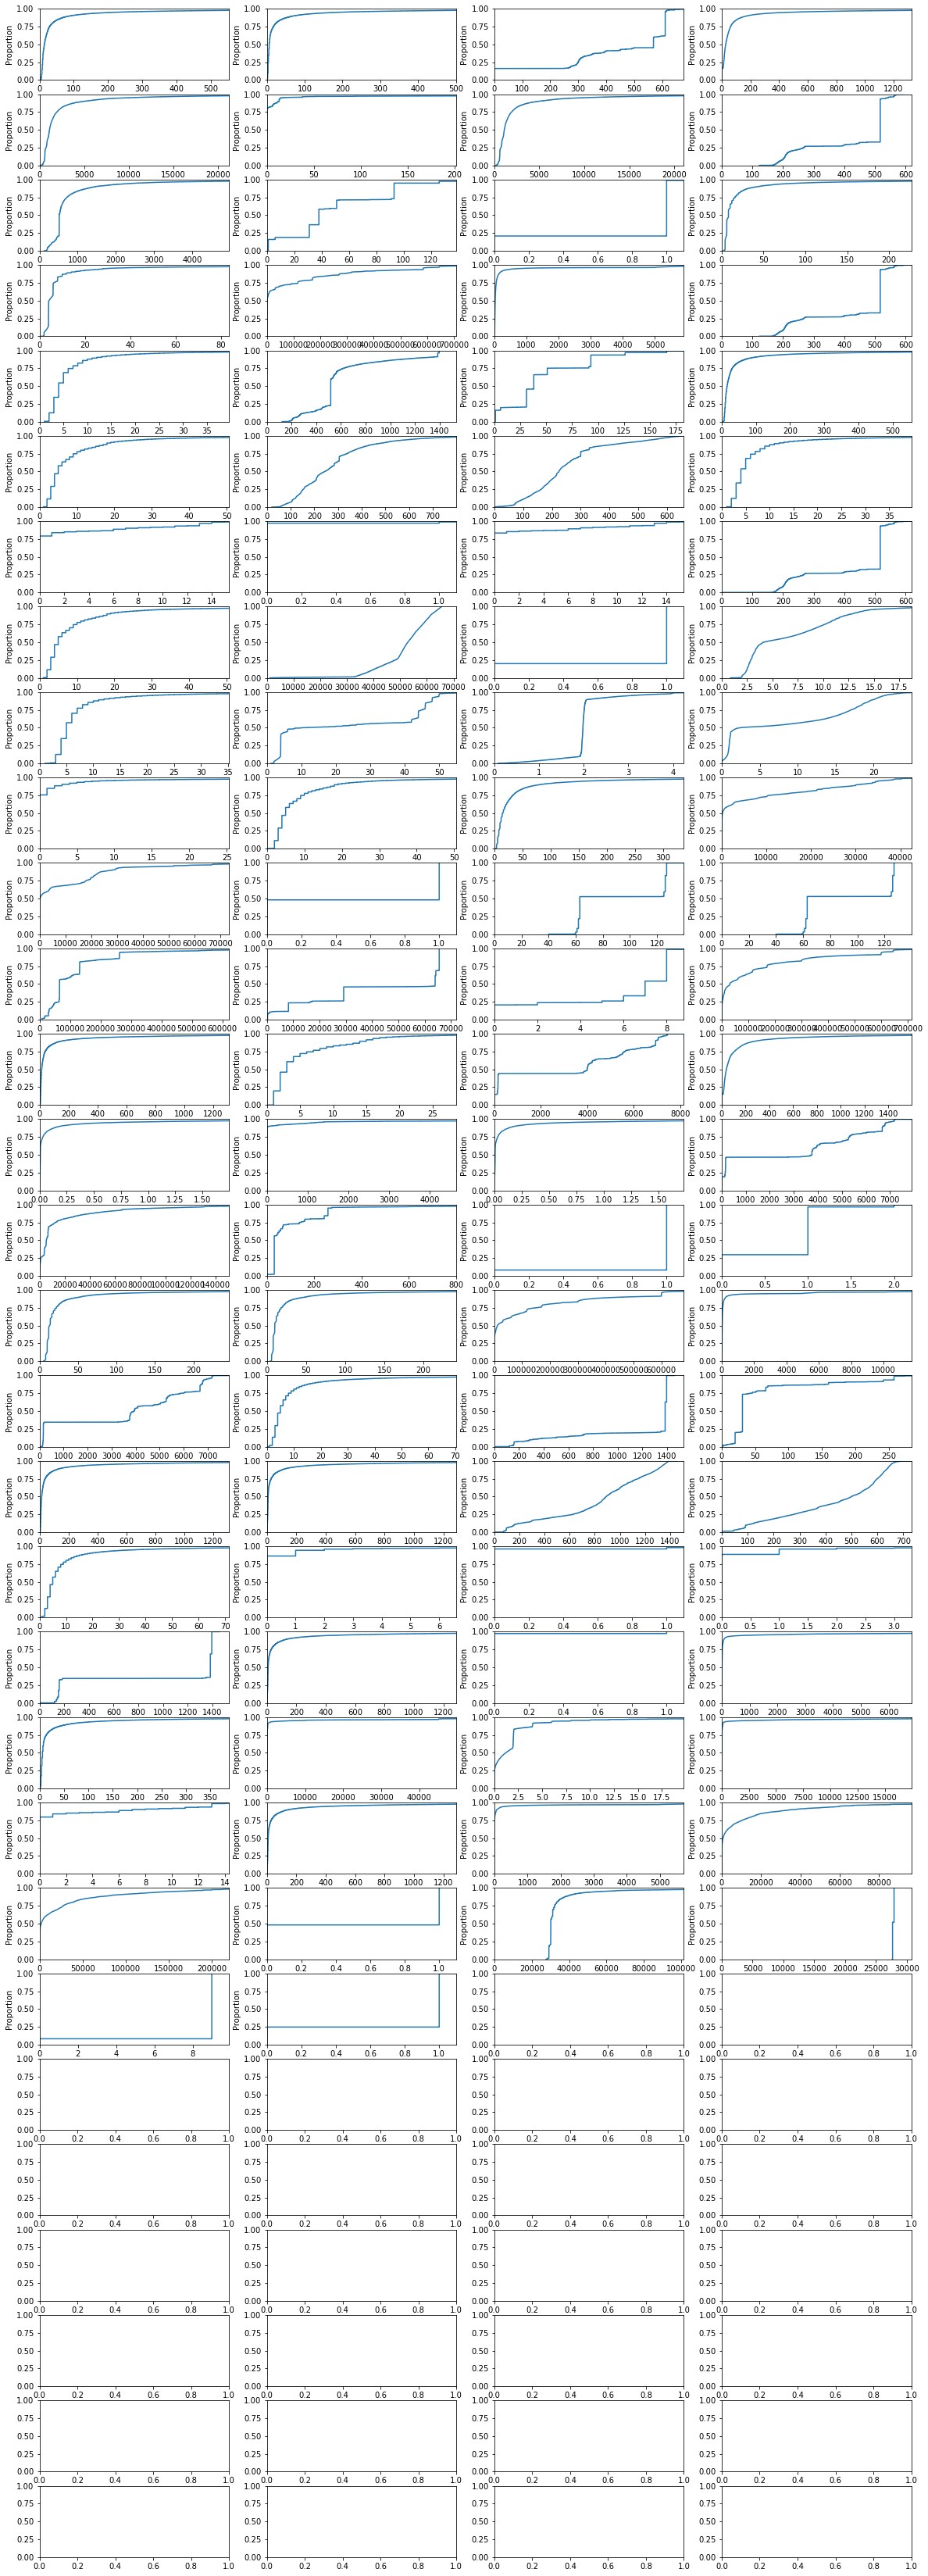

In [40]:
import statistics
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(30, 4, figsize=(20, 60))
ax = ax.flatten()  

j = 0
for i in df_test.columns:
    if i.startswith("_"):
        if df_test[i].quantile(0.025) == df_test[i].quantile(0.975):
            print(i, "90% of its data equal to each other")
            continue
        
        sns.ecdfplot(
            data=df_test,
            x=i,
            #hue='label',
            ax=ax[j]
        )
        high = df_test[i].quantile(0.975)
        ax[j].set_xlim(0, high*1.1)
        j += 1





In [38]:
print(set(df_test['_s_pkts_ooo']))

{0.0, 1.0, 2.0, 4.0, 5.0, 6.0, 15.0}


KeyError: 'domain'